# Milestone 1 — Explore data statistics and shape

**Data:** OPTN kidney waitlist extract

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#52514e"

df = pd.read_csv(
    "../data/restricted/kidney_waitlist_analytic.csv.gz",
    dtype={
        "PREV_TX": "string",
        "TX_DATE": "string",
        "DON_TY": "string",
        "MULTIORG": "string",
        "ORGAN": "string",
        "TRR_ID_CODE": "string",
    },
    low_memory=False,
)

df.shape

(494862, 38)

In [4]:
df.head()

,ON_DIALYSIS,A2A2B_ELIGIBILITY,GENDER,ABO,BMI_TCR,FUNC_STAT_TCR,INIT_STAT,INIT_CPRA,END_CPRA,REM_CD,DAYSWAIT_CHRON,END_STAT,INIT_AGE,DIALYSIS_DATE,END_DATE,INIT_DATE,ETHCAT,PT_CODE,DAYSWAIT_ALLOC,COMPOSITE_DEATH_DATE,REGION,WL_ID_CODE,PREV_TX,TX_DATE,DON_TY,DIAG_KI,MULTIORG,ORGAN,PSTATUS,PTIME,TRR_ID_CODE,DONOR_ID,LISTING_CTR_CODE,outcome,event_adverse,event_transplant,censored,days_to_event
0,Y,NaN,F,B,31.63,2080.0,4099,0.0,0.0,8.0,287.0,4099,53,2018-03-30,2021-01-06,2020-03-25,2,1343681,1013.0,2021-01-06,8,1526706,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,NaN,NaN,<NA>,NaN,13609,died,1,0,0,287.0
1,Y,NaN,M,A,30.04,2070.0,4099,0.0,NaN,24.0,2322.0,4099,56,2017-08-16,2026-06-24,2020-02-14,1,1337977,3234.0,NaN,5,1519605,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,NaN,NaN,<NA>,NaN,6975,removed_administrative,0,0,0,2322.0
2,N,NaN,F,O,32.85,2070.0,4099,0.0,0.0,8.0,604.0,4099,47,NaN,2022-01-21,2020-05-27,1,1350622,604.0,2022-01-21,11,1535094,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,NaN,NaN,<NA>,NaN,19716,died,1,0,0,604.0
3,Y,NaN,M,A,20.00,2090.0,4099,0.0,0.0,13.0,909.0,4099,61,2019-01-05,2022-09-28,2020-04-02,5,1344761,1362.0,2025-02-08,7,1527782,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,NaN,NaN,<NA>,NaN,8587,removed_too_sick,1,0,0,909.0
4,Y,NaN,M,AB,23.30,2070.0,4010,0.0,0.0,13.0,231.0,4099,61,2019-01-10,2020-09-23,2020-02-05,2,1288889,622.0,2021-03-01,7,1517273,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,NaN,NaN,<NA>,NaN,18352,removed_too_sick,1,0,0,231.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494862 entries, 0 to 494861
Data columns (total 38 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ON_DIALYSIS           494862 non-null  object 
 1   A2A2B_ELIGIBILITY     38258 non-null   float64
 2   GENDER                494862 non-null  object 
 3   ABO                   494862 non-null  object 
 4   BMI_TCR               493304 non-null  float64
 5   FUNC_STAT_TCR         490887 non-null  float64
 6   INIT_STAT             494862 non-null  int64  
 7   INIT_CPRA             352121 non-null  float64
 8   END_CPRA              352414 non-null  float64
 9   REM_CD                391562 non-null  float64
 10  DAYSWAIT_CHRON        494809 non-null  float64
 11  END_STAT              494862 non-null  int64  
 12  INIT_AGE              494862 non-null  int64  
 13  DIALYSIS_DATE         360617 non-null  object 
 14  END_DATE              494862 non-null  object 
 15  

## Shape of each column

In [6]:
schema = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(1),
    "n_unique": df.nunique(),
})

schema.sort_values("pct_missing", ascending=False)

,dtype,n_missing,pct_missing,n_unique
MULTIORG,string,483004,97.6,1
A2A2B_ELIGIBILITY,float64,456604,92.3,2
COMPOSITE_DEATH_DATE,object,398512,80.5,4101
PTIME,float64,267350,54.0,3982
DIAG_KI,float64,265540,53.7,69
DON_TY,string,264107,53.4,3
PREV_TX,string,264107,53.4,2
ORGAN,string,264107,53.4,2
PSTATUS,float64,264107,53.4,2
TRR_ID_CODE,string,264107,53.4,230755


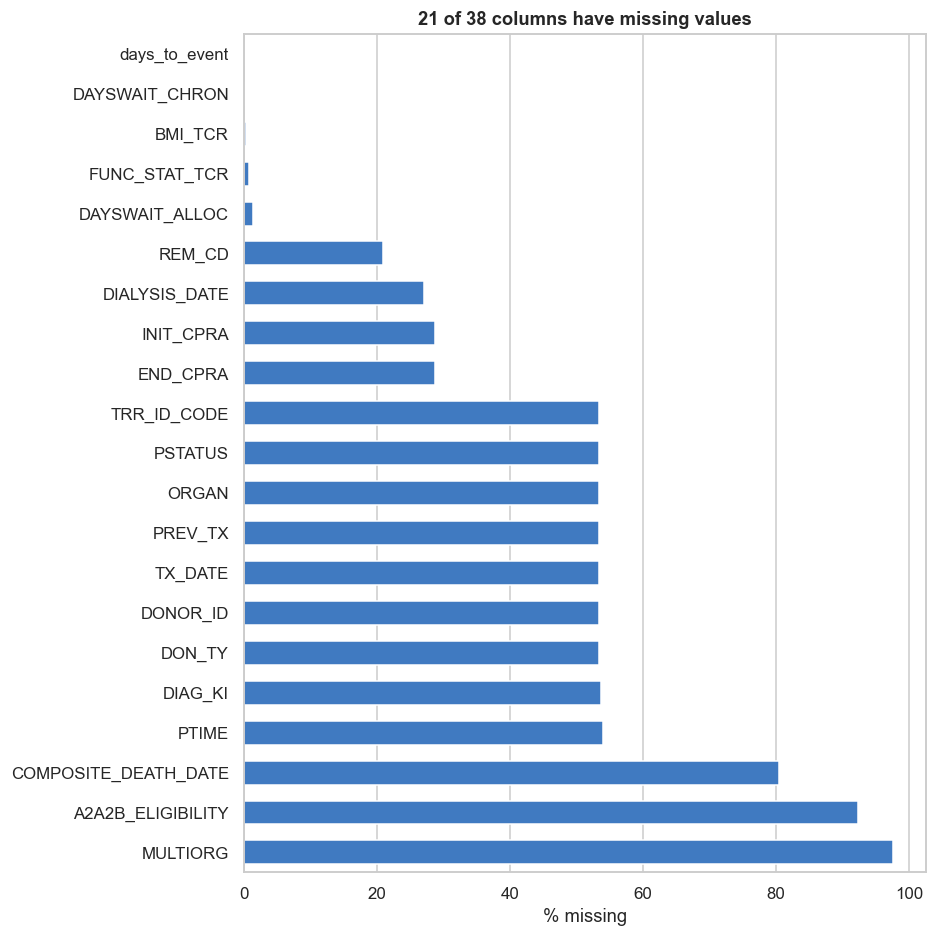

In [7]:
missing = schema.loc[schema["n_missing"] > 0, "pct_missing"].sort_values()

plt.figure(figsize=(8, 0.4 * len(missing) + 1.5))
sns.barplot(x=missing.values, y=missing.index, color=BLUE, width=0.6)
plt.xlabel("% missing")
plt.ylabel("")
plt.title(f"{len(missing)} of {df.shape[1]} columns have missing values")
plt.savefig("../reports/figures/01_missingness.png", dpi=150, bbox_inches="tight")
plt.show()

## Outcome

In [8]:
df["outcome"].value_counts(dropna=False)

outcome
transplanted              234429
still_waiting             103300
removed_administrative     45332
transplanted_elsewhere     37243
removed_too_sick           35219
died                       34524
unknown                     4815
Name: count, dtype: int64

In [9]:
for col in ["event_adverse", "event_transplant", "censored"]:
    print(f"{col:<18} {df[col].sum():>7,}  ({df[col].mean() * 100:5.2f}%)")

print(f"\nREADME reference: adverse 14.1%, censored 20.9%")

event_adverse       69,743  (14.09%)
event_transplant   234,429  (47.37%)
censored           103,300  (20.87%)

README reference: adverse 14.1%, censored 20.9%


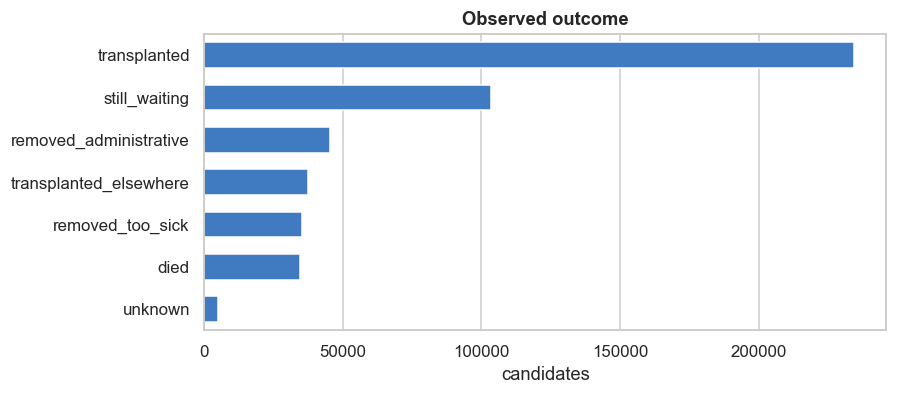

In [10]:
counts = df["outcome"].value_counts()

plt.figure(figsize=(8, 3.5))
sns.barplot(x=counts.values, y=counts.index, color=BLUE, width=0.6)
plt.xlabel("candidates")
plt.ylabel("")
plt.title("Observed outcome")
plt.savefig("../reports/figures/02_outcome.png", dpi=150, bbox_inches="tight")
plt.show()

## Numeric columns

In [11]:
num_df = df.select_dtypes(include=["int64", "float64"])

num_df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
A2A2B_ELIGIBILITY,38258.0,0.28,0.45,0.00,0.00,0.00,1.00,1.00
BMI_TCR,493304.0,64.70,3141.12,0.18,24.65,28.53,32.85,430226.67
FUNC_STAT_TCR,490887.0,2106.33,343.74,1.00,2070.00,2080.00,2090.00,4100.00
INIT_STAT,494862.0,4036.22,40.56,4010.00,4010.00,4010.00,4099.00,4099.00
INIT_CPRA,352121.0,9.79,24.80,0.00,0.00,0.00,0.00,100.00
END_CPRA,352414.0,29.22,36.41,0.00,0.00,6.86,56.93,100.00
REM_CD,391562.0,9.15,5.93,4.00,4.00,8.00,14.00,45.00
DAYSWAIT_CHRON,494809.0,649.53,654.24,0.00,144.00,433.00,965.00,4200.00
END_STAT,494862.0,4038.29,41.44,4010.00,4010.00,4010.00,4099.00,4099.00
INIT_AGE,494862.0,51.87,14.60,0.00,43.00,54.00,63.00,91.00


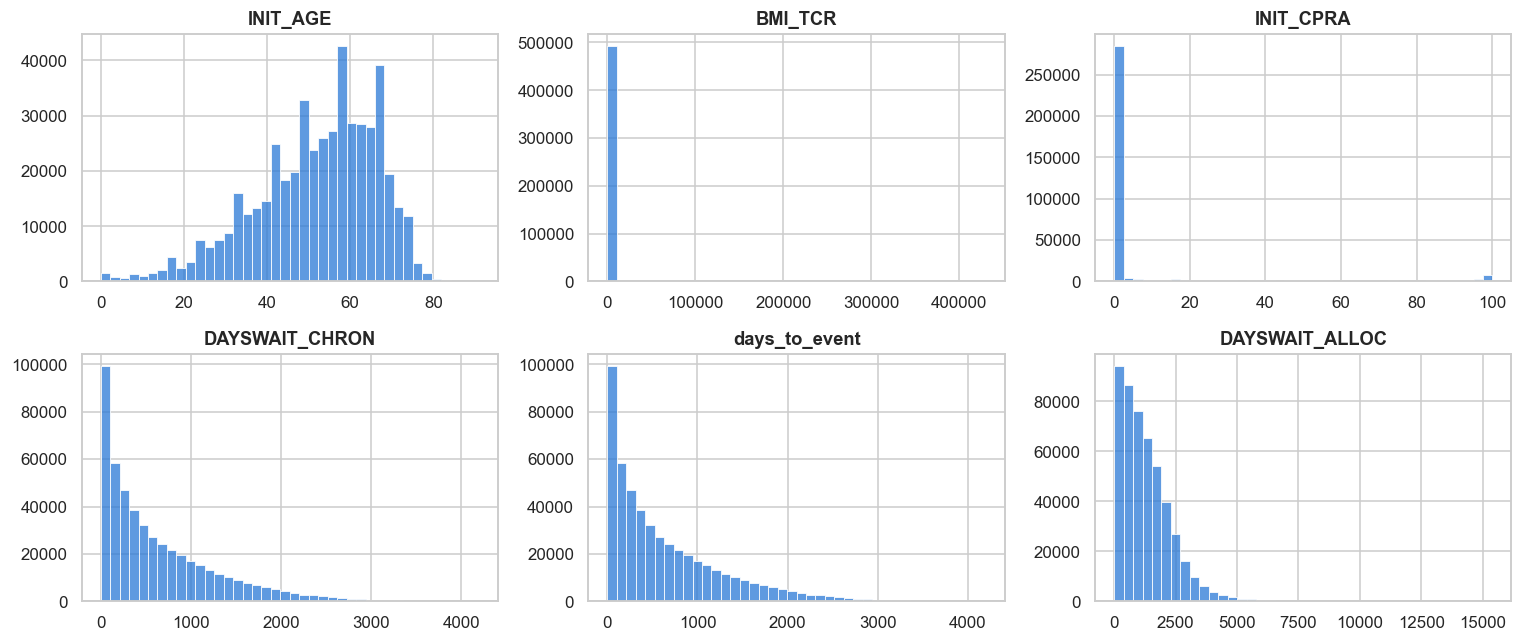

In [12]:
cols = ["INIT_AGE", "BMI_TCR", "INIT_CPRA", "DAYSWAIT_CHRON", "days_to_event", "DAYSWAIT_ALLOC"]

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, col in zip(axes.ravel(), cols):
    sns.histplot(df[col].dropna(), bins=40, color=BLUE, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.tight_layout()
plt.savefig("../reports/figures/03_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## Correlation with `event_adverse`

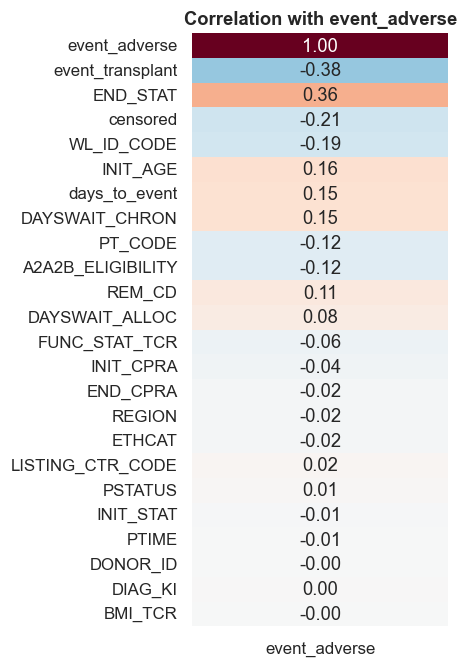

In [13]:
corr_matrix = num_df.corr()[["event_adverse"]]
corr_matrix = corr_matrix.loc[corr_matrix["event_adverse"].abs().sort_values(ascending=False).index]

plt.figure(figsize=(3, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, cbar=False)
plt.title("Correlation with event_adverse")
plt.ylabel("")
plt.savefig("../reports/figures/04_correlation.png", dpi=150, bbox_inches="tight")
plt.show()